In [4]:
RANDOM_STATE = 42
OUT_DIR = "runs2"
RUN_NAME = "elliptic"

In [5]:

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone
from scipy.stats import randint, uniform




DATA_DIR = r"D:\elliptic\Elliptic_Dataset"
TXS_FEATURES_FILE = "txs_features.csv"
TXS_CLASSES_FILE  = "txs_classes.csv"
TXS_EDGELIST_FILE = "txs_edgelist.csv"  

In [6]:

import os

df_txs_features = pd.read_csv(os.path.join(DATA_DIR, TXS_FEATURES_FILE))
df_txs_classes  = pd.read_csv(os.path.join(DATA_DIR, TXS_CLASSES_FILE))

print("txs_features shape:", df_txs_features.shape)
print("txs_classes  shape:", df_txs_classes.shape)
print("txs_features columns:", df_txs_features.columns.tolist())
print("txs_classes  columns:", df_txs_classes.columns.tolist())


txs_features shape: (203769, 184)
txs_classes  shape: (203769, 2)
txs_features columns: ['txId', 'Time step', 'Local_feature_1', 'Local_feature_2', 'Local_feature_3', 'Local_feature_4', 'Local_feature_5', 'Local_feature_6', 'Local_feature_7', 'Local_feature_8', 'Local_feature_9', 'Local_feature_10', 'Local_feature_11', 'Local_feature_12', 'Local_feature_13', 'Local_feature_14', 'Local_feature_15', 'Local_feature_16', 'Local_feature_17', 'Local_feature_18', 'Local_feature_19', 'Local_feature_20', 'Local_feature_21', 'Local_feature_22', 'Local_feature_23', 'Local_feature_24', 'Local_feature_25', 'Local_feature_26', 'Local_feature_27', 'Local_feature_28', 'Local_feature_29', 'Local_feature_30', 'Local_feature_31', 'Local_feature_32', 'Local_feature_33', 'Local_feature_34', 'Local_feature_35', 'Local_feature_36', 'Local_feature_37', 'Local_feature_38', 'Local_feature_39', 'Local_feature_40', 'Local_feature_41', 'Local_feature_42', 'Local_feature_43', 'Local_feature_44', 'Local_feature_45',

In [7]:


df = df_txs_features.merge(df_txs_classes, on="txId", how="left")



print("\nOriginal class distribution:")
print(df["class"].value_counts(dropna=False))


df = df.dropna(subset=["class"]).copy()
df["class"] = df["class"].astype(int)
df = df[df["class"] != 3].copy()


df["label"] = (df["class"] == 2).astype(int)

LABEL_COL = "label"
print("\nLabel distribution after removing unknown samples (0=licit,1=illicit):")
print(df[LABEL_COL].value_counts())


Original class distribution:
class
3    157205
2     42019
1      4545
Name: count, dtype: int64

Label distribution after removing unknown samples (0=licit,1=illicit):
label
1    42019
0     4545
Name: count, dtype: int64


In [8]:

possible_ts_cols = ["Time step", "time_step"]
ts_col = None
for c in possible_ts_cols:
    if c in df.columns:
        ts_col = c
        break

# if ts_col is None:
#     raise ValueError("Không tìm thấy cột time-step (ví dụ 'Time step' hoặc 'time_step')!")

drop_id_cols = ["txId", ts_col]
drop_label_cols = ["class", LABEL_COL]

cols_to_drop = [c for c in drop_id_cols + drop_label_cols if c in df.columns]

feature_cols = [c for c in df.columns if c not in cols_to_drop]

txid = df["txId"].astype(int).values

X_df = df[feature_cols].copy()
y = df[LABEL_COL].values
time_steps = df[ts_col].values

print("\nNumber of feature:", len(feature_cols))



num_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
X_df = X_df[num_cols].copy()
print("\nNumber of feature numeric:", len(num_cols))


Number of feature: 182

Number of feature numeric: 182


In [9]:

unique_ts = np.sort(df[ts_col].unique())
n_ts = len(unique_ts)


if n_ts == 49:
    train_ts = unique_ts[:30]
    val_ts   = unique_ts[30:34]
    test_ts  = unique_ts[34:]
elif n_ts >= 50:
    train_ts = unique_ts[:30]
    val_ts   = unique_ts[30:40]
    test_ts  = unique_ts[40:50]
else:

    idx_train_end = int(0.6 * n_ts)
    idx_val_end   = int(0.8 * n_ts)
    train_ts = unique_ts[:idx_train_end]
    val_ts   = unique_ts[idx_train_end:idx_val_end]
    test_ts  = unique_ts[idx_val_end:]

print("\nTime-step TRAIN:", train_ts[0], "->", train_ts[-1])
print("Time-step VAL  :", val_ts[0],   "->", val_ts[-1])
print("Time-step TEST :", test_ts[0],  "->", test_ts[-1])

train_mask = df[ts_col].isin(train_ts)
val_mask   = df[ts_col].isin(val_ts)
test_mask  = df[ts_col].isin(test_ts)

X_train = X_df[train_mask].values
y_train = y[train_mask]

X_val   = X_df[val_mask].values
y_val   = y[val_mask]

X_test  = X_df[test_mask].values
y_test  = y[test_mask]


txid_train = txid[train_mask]
txid_val   = txid[val_mask]
txid_test  = txid[test_mask]
print("txid_test sample:", txid_test[:5])

print("\nSize:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

print("\nLabel distribution in the training set:")
print(pd.Series(y_train).value_counts())
print("\nLabel distribution in the validation set:")
print(pd.Series(y_val).value_counts())
print("\nLabel distribution in the testing set:")
print(pd.Series(y_test).value_counts())


Time-step TRAIN: 1 -> 30
Time-step VAL  : 31 -> 34
Time-step TEST : 35 -> 49
txid_test sample: [1813992 2234847 2364754 2365784 2503693]

Size:
X_train: (26905, 182) y_train: (26905,)
X_val  : (2989, 182) y_val  : (2989,)
X_test : (16670, 182) y_test : (16670,)

Label distribution in the training set:
1    23951
0     2954
Name: count, dtype: int64

Label distribution in the validation set:
1    2481
0     508
Name: count, dtype: int64

Label distribution in the testing set:
1    15587
0     1083
Name: count, dtype: int64


In [10]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [11]:

import os
import numpy as np

def load_saved_proba(save_dirs, filename, txid_test, fill=0.5):

    for d in save_dirs:
        f = os.path.join(d, filename)
        if os.path.exists(f):
            npz = np.load(f, allow_pickle=True)
            txid = npz["txid"].astype(int)
            proba = npz["proba"].astype(float)
            thr = float(npz["threshold"]) if "threshold" in npz.files else 0.5

            mp = {int(t): float(p) for t, p in zip(txid.tolist(), proba.tolist())}
            aligned = np.array([mp.get(int(t), np.nan) for t in txid_test], dtype=float)

            missing = int(np.isnan(aligned).sum())
            if missing > 0:
                print(f"[WARN] Missing {missing}/{len(aligned)} txId in {f}. Fill={fill}")
                aligned = np.nan_to_num(aligned, nan=fill)

            return aligned, thr, f

    return None, 0.5, None



GNN_SAVE_CANDIDATES = [
    "gnn_saved",
    r"D:\elliptic\ellipticv2\gnn_saved",
]
gnn_proba_test, gnn_threshold, gnn_file = load_saved_proba(
    GNN_SAVE_CANDIDATES, "gnn_test_preds.npz", txid_test, fill=0.5
)
if gnn_proba_test is not None:
    print("[OK] Loaded GNN preds:", gnn_proba_test.shape, "| thr:", gnn_threshold, "| file:", gnn_file)
else:
    print("[INFO] Could not find GNN preds in:", GNN_SAVE_CANDIDATES)



SAGE_SAVE_CANDIDATES = [
    "sage_saved",
    r"D:\elliptic\ellipticv2\sage_saved",
]
sage_proba_test, sage_threshold, sage_file = load_saved_proba(
    SAGE_SAVE_CANDIDATES, "gnn_test_preds.npz", txid_test, fill=0.5
)
if sage_proba_test is not None:
    print("[OK] Loaded SAGE preds:", sage_proba_test.shape, "| thr:", sage_threshold, "| file:", sage_file)
else:
    print("[INFO] Could not find SAGE preds in:", SAGE_SAVE_CANDIDATES)


[WARN] Missing 324/16670 txId in D:\elliptic\ellipticv2\gnn_saved\gnn_test_preds.npz. Fill=0.5
[OK] Loaded GNN preds: (16670,) | thr: 0.5 | file: D:\elliptic\ellipticv2\gnn_saved\gnn_test_preds.npz
[WARN] Missing 324/16670 txId in D:\elliptic\ellipticv2\sage_saved\gnn_test_preds.npz. Fill=0.5
[OK] Loaded SAGE preds: (16670,) | thr: 0.5 | file: D:\elliptic\ellipticv2\sage_saved\gnn_test_preds.npz


In [12]:

from sklearn.metrics import roc_auc_score


def sample_param(dist, rng):

    if hasattr(dist, "rvs"):

        return dist.rvs(random_state=rng)

    dist = list(dist)
    return dist[rng.randint(0, len(dist))]

def random_search_single_model(
    name,
    base_estimator,
    param_dist,
    X_train, y_train,
    X_val,   y_val,
    n_iter=30,
    scoring="macro"
):

    print(f"\n===== {name} Random search    =====")
    rng = np.random.RandomState(RANDOM_STATE)
    best_f1 = -1.0
    best_params = None

    for i in range(n_iter):
        params = {k: sample_param(v, rng) for k, v in param_dist.items()}

        model = clone(base_estimator)
        model.set_params(**params)
        model.fit(X_train, y_train)

        y_val_pred = model.predict(X_val)

        y_val_score = None
        if hasattr(model, 'predict_proba'):
            try:
                y_val_score = model.predict_proba(X_val)[:, 1]
            except Exception:
                y_val_score = None
        elif hasattr(model, 'decision_function'):
            try:
                y_val_score = model.decision_function(X_val)
            except Exception:
                y_val_score = None

        auc_val = np.nan
        if y_val_score is not None:
            try:
                auc_val = roc_auc_score(y_val, y_val_score)
            except Exception:
                auc_val = np.nan

        f1_macro = f1_score(y_val, y_val_pred, average="macro")

        print(f"Iter {i+1:02d}/{n_iter}: F1_macro(val) = {f1_macro:.4f}, AUC(val) = {auc_val:.4f}, params = {params}")

        if f1_macro > best_f1:
            best_f1 = f1_macro
            best_params = params

    print(f"\n>>> {name} – best F1_macro(val) = {best_f1:.4f}")
    print("Best params:", best_params)


    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val])

    best_model = clone(base_estimator)
    best_model.set_params(**best_params)
    best_model.fit(X_train_full, y_train_full)

    return best_model


n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0
print("\nscale_pos_weight (train):", scale_pos_weight)


scale_pos_weight (train): 0.12333514258277316


In [13]:


# 1) RandomForest
rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_param_dist = {
    "n_estimators": randint(200, 600),
    "max_depth": randint(3, 30),
    "min_samples_split": randint(2, 50),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

best_rf = random_search_single_model(
    "RandomForest",
    rf_base,
    rf_param_dist,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    n_iter=30
)







===== RandomForest Random search    =====
Iter 01/30: F1_macro(val) = 0.9664, AUC(val) = 0.9957, params = {'n_estimators': 302, 'max_depth': 22, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': None, 'class_weight': 'balanced', 'criterion': 'gini'}
Iter 02/30: F1_macro(val) = 0.9486, AUC(val) = 0.9934, params = {'n_estimators': 220, 'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 11, 'max_features': None, 'class_weight': 'balanced', 'criterion': 'gini'}
Iter 03/30: F1_macro(val) = 0.9764, AUC(val) = 0.9968, params = {'n_estimators': 299, 'max_depth': 10, 'min_samples_split': 25, 'min_samples_leaf': 3, 'max_features': 'log2', 'class_weight': None, 'criterion': 'entropy'}
Iter 04/30: F1_macro(val) = 0.9704, AUC(val) = 0.9970, params = {'n_estimators': 543, 'max_depth': 14, 'min_samples_split': 31, 'min_samples_leaf': 6, 'max_features': 'log2', 'class_weight': 'balanced', 'criterion': 'entropy'}
Iter 05/30: F1_macro(val) = 0.8332, AUC(val) = 0.9828, params = 

In [14]:
# 2) XGBoost
xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    tree_method="hist",     
    eval_metric="logloss",
    use_label_encoder=False
)

xgb_param_dist = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(3, 12),
    "learning_rate": uniform(0.01, 0.29),
    "subsample": uniform(0.6, 0.4),     
    "colsample_bytree": uniform(0.6, 0.4), 
    "min_child_weight": randint(1, 10),
    "reg_lambda": uniform(0, 5),
    "objective": ["binary:logistic"],     
    "eval_metric": ["logloss", "aucpr"],    
    "scale_pos_weight": [scale_pos_weight]
}

best_xgb = random_search_single_model(
    "XGBoost",
    xgb_base,
    xgb_param_dist,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    n_iter=30
)


===== XGBoost Random search    =====


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 01/30: F1_macro(val) = 0.9682, AUC(val) = 0.9967, params = {'n_estimators': 302, 'max_depth': 6, 'learning_rate': np.float64(0.28570714885887566), 'subsample': np.float64(0.892797576724562), 'colsample_bytree': np.float64(0.8394633936788146), 'min_child_weight': 7, 'reg_lambda': np.float64(2.229163764267956), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 02/30: F1_macro(val) = 0.9435, AUC(val) = 0.9939, params = {'n_estimators': 530, 'max_depth': 10, 'learning_rate': np.float64(0.10677549723031632), 'subsample': np.float64(0.6571467271687763), 'colsample_bytree': np.float64(0.8603553891795411), 'min_child_weight': 5, 'reg_lambda': np.float64(4.8495492608099715), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 03/30: F1_macro(val) = 0.9386, AUC(val) = 0.9978, params = {'n_estimators': 613, 'max_depth': 8, 'learning_rate': np.float64(0.010225842093894155), 'subsample': np.float64(0.996884623716487), 'colsample_bytree': np.float64(0.8469926038510867), 'min_child_weight': 6, 'reg_lambda': np.float64(0.03533152609858703), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 04/30: F1_macro(val) = 0.9721, AUC(val) = 0.9977, params = {'n_estimators': 760, 'max_depth': 5, 'learning_rate': np.float64(0.12091397746747719), 'subsample': np.float64(0.9932923543227152), 'colsample_bytree': np.float64(0.786705157299192), 'min_child_weight': 5, 'reg_lambda': np.float64(3.0377242595071916), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 05/30: F1_macro(val) = 0.9676, AUC(val) = 0.9963, params = {'n_estimators': 366, 'max_depth': 4, 'learning_rate': np.float64(0.2851768058034666), 'subsample': np.float64(0.9862528132298237), 'colsample_bytree': np.float64(0.9233589392465844), 'min_child_weight': 9, 'reg_lambda': np.float64(0.07983126110107097), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 06/30: F1_macro(val) = 0.9789, AUC(val) = 0.9980, params = {'n_estimators': 539, 'max_depth': 9, 'learning_rate': np.float64(0.18689903075696007), 'subsample': np.float64(0.9332779646944658), 'colsample_bytree': np.float64(0.6693458614031088), 'min_child_weight': 1, 'reg_lambda': np.float64(1.2938999080000846), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 07/30: F1_macro(val) = 0.9681, AUC(val) = 0.9970, params = {'n_estimators': 587, 'max_depth': 4, 'learning_rate': np.float64(0.13329520360246094), 'subsample': np.float64(0.6831766651472755), 'colsample_bytree': np.float64(0.8270801311279966), 'min_child_weight': 2, 'reg_lambda': np.float64(3.8756641168055728), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:43] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 08/30: F1_macro(val) = 0.9681, AUC(val) = 0.9966, params = {'n_estimators': 401, 'max_depth': 6, 'learning_rate': np.float64(0.18339099385521468), 'subsample': np.float64(0.9687496940092467), 'colsample_bytree': np.float64(0.6353970008207678), 'min_child_weight': 7, 'reg_lambda': np.float64(2.6041713001291185), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:45] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 09/30: F1_macro(val) = 0.9483, AUC(val) = 0.9943, params = {'n_estimators': 495, 'max_depth': 7, 'learning_rate': np.float64(0.12271641400994977), 'subsample': np.float64(0.7085396127095583), 'colsample_bytree': np.float64(0.9314950036607718), 'min_child_weight': 9, 'reg_lambda': np.float64(1.4046725484369038), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 10/30: F1_macro(val) = 0.9398, AUC(val) = 0.9927, params = {'n_estimators': 692, 'max_depth': 11, 'learning_rate': np.float64(0.09591931665418388), 'subsample': np.float64(0.6661067756252009), 'colsample_bytree': np.float64(0.6062545626964776), 'min_child_weight': 9, 'reg_lambda': np.float64(3.861223846483287), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 11/30: F1_macro(val) = 0.9696, AUC(val) = 0.9974, params = {'n_estimators': 671, 'max_depth': 5, 'learning_rate': np.float64(0.21498862971580895), 'subsample': np.float64(0.8916028672163949), 'colsample_bytree': np.float64(0.9085081386743783), 'min_child_weight': 5, 'reg_lambda': np.float64(4.631504392566745), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 12/30: F1_macro(val) = 0.9660, AUC(val) = 0.9966, params = {'n_estimators': 240, 'max_depth': 9, 'learning_rate': np.float64(0.2565111875590418), 'subsample': np.float64(0.7797802696552814), 'colsample_bytree': np.float64(0.6381640465961645), 'min_child_weight': 7, 'reg_lambda': np.float64(1.554911608578311), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:54] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 13/30: F1_macro(val) = 0.9700, AUC(val) = 0.9977, params = {'n_estimators': 298, 'max_depth': 10, 'learning_rate': np.float64(0.08966931996711859), 'subsample': np.float64(0.8244973703390804), 'colsample_bytree': np.float64(0.7531707499015159), 'min_child_weight': 3, 'reg_lambda': np.float64(3.803925243084487), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 14/30: F1_macro(val) = 0.9700, AUC(val) = 0.9982, params = {'n_estimators': 702, 'max_depth': 9, 'learning_rate': np.float64(0.021725740966145088), 'subsample': np.float64(0.8842651558743149), 'colsample_bytree': np.float64(0.6443563283247326), 'min_child_weight': 3, 'reg_lambda': np.float64(0.15714592843367126), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 15/30: F1_macro(val) = 0.9637, AUC(val) = 0.9969, params = {'n_estimators': 440, 'max_depth': 6, 'learning_rate': np.float64(0.17334991587315127), 'subsample': np.float64(0.878206434570451), 'colsample_bytree': np.float64(0.6557325817623503), 'min_child_weight': 7, 'reg_lambda': np.float64(2.0519146151781484), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 16/30: F1_macro(val) = 0.9749, AUC(val) = 0.9978, params = {'n_estimators': 740, 'max_depth': 6, 'learning_rate': np.float64(0.2834275354618145), 'subsample': np.float64(0.8395461865954144), 'colsample_bytree': np.float64(0.8779139732158818), 'min_child_weight': 2, 'reg_lambda': np.float64(3.1217702406689662), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 17/30: F1_macro(val) = 0.9622, AUC(val) = 0.9967, params = {'n_estimators': 227, 'max_depth': 6, 'learning_rate': np.float64(0.26884210956209353), 'subsample': np.float64(0.8157368967662603), 'colsample_bytree': np.float64(0.922976062065625), 'min_child_weight': 9, 'reg_lambda': np.float64(1.5900173748593194), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 18/30: F1_macro(val) = 0.9657, AUC(val) = 0.9966, params = {'n_estimators': 584, 'max_depth': 11, 'learning_rate': np.float64(0.19783013495699506), 'subsample': np.float64(0.6002081507981263), 'colsample_bytree': np.float64(0.7410275425336676), 'min_child_weight': 3, 'reg_lambda': np.float64(0.03476065265595352), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 19/30: F1_macro(val) = 0.9567, AUC(val) = 0.9953, params = {'n_estimators': 610, 'max_depth': 11, 'learning_rate': np.float64(0.15060069169410512), 'subsample': np.float64(0.8769744131561081), 'colsample_bytree': np.float64(0.7077649335194086), 'min_child_weight': 8, 'reg_lambda': np.float64(4.714548519562596), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 20/30: F1_macro(val) = 0.9558, AUC(val) = 0.9949, params = {'n_estimators': 671, 'max_depth': 11, 'learning_rate': np.float64(0.12711248960683183), 'subsample': np.float64(0.6259568988435926), 'colsample_bytree': np.float64(0.7015661655737379), 'min_child_weight': 7, 'reg_lambda': np.float64(2.4862425294619275), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 21/30: F1_macro(val) = 0.9722, AUC(val) = 0.9978, params = {'n_estimators': 280, 'max_depth': 3, 'learning_rate': np.float64(0.29321833719146934), 'subsample': np.float64(0.7644148053272926), 'colsample_bytree': np.float64(0.6132202931602193), 'min_child_weight': 1, 'reg_lambda': np.float64(3.171756723506819), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 22/30: F1_macro(val) = 0.9733, AUC(val) = 0.9980, params = {'n_estimators': 329, 'max_depth': 7, 'learning_rate': np.float64(0.15194130048049329), 'subsample': np.float64(0.9942601816442402), 'colsample_bytree': np.float64(0.6968221086046001), 'min_child_weight': 4, 'reg_lambda': np.float64(0.40426663166357624), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 23/30: F1_macro(val) = 0.9528, AUC(val) = 0.9941, params = {'n_estimators': 322, 'max_depth': 3, 'learning_rate': np.float64(0.22118274109743927), 'subsample': np.float64(0.7471132530877013), 'colsample_bytree': np.float64(0.8529223322374317), 'min_child_weight': 6, 'reg_lambda': np.float64(1.9941222122227653), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 24/30: F1_macro(val) = 0.9226, AUC(val) = 0.9927, params = {'n_estimators': 343, 'max_depth': 3, 'learning_rate': np.float64(0.05370808774997454), 'subsample': np.float64(0.8032795106962874), 'colsample_bytree': np.float64(0.8783251227163527), 'min_child_weight': 3, 'reg_lambda': np.float64(2.954464715941209), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 25/30: F1_macro(val) = 0.9670, AUC(val) = 0.9966, params = {'n_estimators': 602, 'max_depth': 5, 'learning_rate': np.float64(0.24475530338051746), 'subsample': np.float64(0.7394663949166917), 'colsample_bytree': np.float64(0.6384706204365683), 'min_child_weight': 9, 'reg_lambda': np.float64(3.45468869051233), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 26/30: F1_macro(val) = 0.9692, AUC(val) = 0.9973, params = {'n_estimators': 750, 'max_depth': 4, 'learning_rate': np.float64(0.2529359307131251), 'subsample': np.float64(0.8702760468157122), 'colsample_bytree': np.float64(0.8940864476963089), 'min_child_weight': 2, 'reg_lambda': np.float64(4.623468091392814), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 27/30: F1_macro(val) = 0.9585, AUC(val) = 0.9955, params = {'n_estimators': 497, 'max_depth': 5, 'learning_rate': np.float64(0.0762795063212169), 'subsample': np.float64(0.6699819708383744), 'colsample_bytree': np.float64(0.9928673373317742), 'min_child_weight': 4, 'reg_lambda': np.float64(2.6482528917800323), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 28/30: F1_macro(val) = 0.9731, AUC(val) = 0.9971, params = {'n_estimators': 503, 'max_depth': 7, 'learning_rate': np.float64(0.2711212365773658), 'subsample': np.float64(0.8532405829093072), 'colsample_bytree': np.float64(0.7356119164194803), 'min_child_weight': 3, 'reg_lambda': np.float64(3.5017891498638565), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 29/30: F1_macro(val) = 0.9823, AUC(val) = 0.9981, params = {'n_estimators': 330, 'max_depth': 6, 'learning_rate': np.float64(0.267255063036884), 'subsample': np.float64(0.9119502183430496), 'colsample_bytree': np.float64(0.8568126584617151), 'min_child_weight': 1, 'reg_lambda': np.float64(0.8081435704730688), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 30/30: F1_macro(val) = 0.9437, AUC(val) = 0.9938, params = {'n_estimators': 303, 'max_depth': 6, 'learning_rate': np.float64(0.17839912021657184), 'subsample': np.float64(0.7489131066246972), 'colsample_bytree': np.float64(0.9760533769831113), 'min_child_weight': 9, 'reg_lambda': np.float64(0.025307919231093434), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}

>>> XGBoost – best F1_macro(val) = 0.9823
Best params: {'n_estimators': 330, 'max_depth': 6, 'learning_rate': np.float64(0.267255063036884), 'subsample': np.float64(0.9119502183430496), 'colsample_bytree': np.float64(0.8568126584617151), 'min_child_weight': 1, 'reg_lambda': np.float64(0.8081435704730688), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:43:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [15]:
# 3) LightGBM
lgbm_base = LGBMClassifier(
    random_state=RANDOM_STATE,
    objective="binary",
    n_jobs=-1
)

lgbm_param_dist = {
    "n_estimators": randint(200, 800),
    "num_leaves": randint(15, 255),
    "max_depth": randint(3, 12),            # -1 = no limit
    "learning_rate": uniform(0.01, 0.29),
    "subsample": uniform(0.6, 0.4),          # bagging_fraction
    "colsample_bytree": uniform(0.6, 0.4),   # feature_fraction
    "min_child_samples": randint(10, 100),
    "reg_lambda": uniform(0, 5),
    # --------- "criterion" kiểu LightGBM: objective + metric ----------
    "objective": ["binary"],                      # có thể thêm "xentropy"
    "metric": ["binary_logloss", "auc", "aucpr"],  # AutoML tự chọn
    "scale_pos_weight": [scale_pos_weight]
} 

best_lgbm = random_search_single_model(
    "LightGBM",
    lgbm_base,
    lgbm_param_dist,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    n_iter=30
)


===== LightGBM Random search    =====
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013582 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 01/30: F1_macro(val) = 0.9739, AUC(val) = 0.9984, params = {'n_estimators': 302, 'num_leaves': 194, 'max_depth': 10, 'learning_rate': np.float64(0.18361096041714062), 'subsample': np.float64(0.6624074561769746), 'colsample_bytree': np.float64(0.662397808134481), 'min_child_samples': 84, 'reg_lambda': np.float64(2.2962444598293357), 'objective': 'binary', 'metric': 'binary_logloss', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013978 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best 

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010316 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009854 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011525 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 05/30: F1_macro(val) = 0.9847, AUC(val) = 0.9985, params = {'n_estimators': 366, 'num_leaves': 32, 'max_depth': 6, 'learning_rate': np.float64(0.28323850914860726), 'subsample': np.float64(0.8253152871382157), 'colsample_bytree': np.float64(0.7541666010159664), 'min_child_samples': 99, 'reg_lambda': np.float64(0.48836057003191935), 'objective': 'binary', 'metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41712
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 06/30: F1_macro(val) = 0.9716, AUC(val) = 0.9971, params = {'n_estimators': 654, 'num_leaves': 186, 'max_depth': 10, 'learning_rate': np.float64(0.019972671123413333), 'subsample': np.float64(0.9637281608315128), 'colsample_bytree': np.float64(0.7035119926400067), 'min_child_samples': 13, 'reg_lambda': np.float64(1.5585553804470549), 'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010498 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 07/30: F1_macro(val) = 0.9795, AUC(val) = 0.9983, params = {'n_estimators': 765, 'num_leaves': 120, 'max_depth': 6, 'learning_rate': np.float64(0.06360779210240283), 'subsample': np.float64(0.9878338511058234), 'colsample_bytree': np.float64(0.9100531293444458), 'min_child_samples': 43, 'reg_lambda': np.float64(1.9757511800090721), 'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011581 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011975 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 09/30: F1_macro(val) = 0.9739, AUC(val) = 0.9977, params = {'n_estimators': 416, 'num_leaves': 202, 'max_depth': 11, 'learning_rate': np.float64(0.09591931665418388), 'subsample': np.float64(0.6661067756252009), 'colsample_bytree': np.float64(0.6062545626964776), 'min_child_samples': 18, 'reg_lambda': np.float64(3.861223846483287), 'objective': 'binary', 'metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010841 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008859 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009671 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009940 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41712
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 13/30: F1_macro(val) = 0.9541, AUC(val) = 0.9957, params = {'n_estimators': 753, 'num_leaves': 138, 'max_depth': 5, 'learning_rate': np.float64(0.019114463849152934), 'subsample': np.float64(0.8545641645055122), 'colsample_bytree': np.float64(0.7257423924305306), 'min_child_samples': 13, 'reg_lambda': np.float64(4.537832369630465), 'objective': 'binary', 'metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 15/30: F1_macro(val) = 0.9824, AUC(val) = 0.9986, params = {'n_estimators': 773, 'num_leaves': 199, 'max_depth': 7, 'learning_rate': np.float64(0.2627235711544381), 'subsample': np.float64(0.9214688307596458), 'colsample_bytree': np.float64(0.6746280235544143), 'min_child_samples': 39, 'reg_lambda': np.float64(4.416401294594341), 'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007727 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010615 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009705 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 18/30: F1_macro(val) = 0.9795, AUC(val) = 0.9982, params = {'n_estimators': 671, 'num_leaves': 247, 'max_depth': 6, 'learning_rate': np.float64(0.11545258468999524), 'subsample': np.float64(0.9887128330883843), 'colsample_bytree': np.float64(0.9849789179768444), 'min_child_samples': 48, 'reg_lambda': np.float64(2.4862425294619275), 'objective': 'binary', 'metric': 'binary_logloss', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008785 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41712
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best 

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011244 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010833 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41712
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 21/30: F1_macro(val) = 0.9411, AUC(val) = 0.9963, params = {'n_estimators': 397, 'num_leaves': 228, 'max_depth': 3, 'learning_rate': np.float64(0.05370808774997454), 'subsample': np.float64(0.8032795106962874), 'colsample_bytree': np.float64(0.8783251227163527), 'min_child_samples': 12, 'reg_lambda': np.float64(2.954464715941209), 'objective': 'binary', 'metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010666 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011883 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 24/30: F1_macro(val) = 0.9744, AUC(val) = 0.9976, params = {'n_estimators': 462, 'num_leaves': 158, 'max_depth': 11, 'learning_rate': np.float64(0.15982440846859414), 'subsample': np.float64(0.7043316699321636), 'colsample_bytree': np.float64(0.9985014799031697), 'min_child_samples': 21, 'reg_lambda': np.float64(2.791467268035488), 'objective': 'binary', 'metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009919 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 25/30: F1_macro(val) = 0.9801, AUC(val) = 0.9981, params = {'n_estimators': 208, 'num_leaves': 247, 'max_depth': 5, 'learning_rate': np.float64(0.21310377069210368), 'subsample': np.float64(0.9386644568953224), 'colsample_bytree': np.float64(0.942529716751237), 'min_child_samples': 63, 'reg_lambda': np.float64(3.899377729288119), 'objective': 'binary', 'metric': 'aucpr', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011022 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011566 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 27/30: F1_macro(val) = 0.9801, AUC(val) = 0.9981, params = {'n_estimators': 537, 'num_leaves': 208, 'max_depth': 8, 'learning_rate': np.float64(0.14004300146601173), 'subsample': np.float64(0.9977829850443283), 'colsample_bytree': np.float64(0.6703701010709381), 'min_child_samples': 77, 'reg_lambda': np.float64(1.1862454374840004), 'objective': 'binary', 'metric': 'binary_logloss', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010555 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best 

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 28/30: F1_macro(val) = 0.9802, AUC(val) = 0.9983, params = {'n_estimators': 703, 'num_leaves': 142, 'max_depth': 10, 'learning_rate': np.float64(0.2562747890433116), 'subsample': np.float64(0.8630451569201374), 'colsample_bytree': np.float64(0.8273234413341887), 'min_child_samples': 85, 'reg_lambda': np.float64(2.5440703841938), 'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 29/30: F1_macro(val) = 0.9818, AUC(val) = 0.9986, params = {'n_estimators': 574, 'num_leaves': 36, 'max_depth': 8, 'learning_rate': np.float64(0.2938789288997526), 'subsample': np.float64(0.794696861183782), 'colsample_bytree': np.float64(0.9624395150874216), 'min_child_samples': 36, 'reg_lambda': np.float64(3.974056517708242), 'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(0.12333514258277316)}
[LightGBM] [Info] Number of positive: 23951, number of negative: 2954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011490 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41708
[LightGBM] [Info] Number of data points in the train set: 26905, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890206 -> initscore=2.092850
[LightGBM] [Info] Start training from score 2.092850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41915
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [16]:

from itertools import combinations
from sklearn.metrics import roc_auc_score

base_models = {
    "RF": best_rf,
    "XGB": best_xgb,
    "LGBM": best_lgbm
}


class StaticProbaModel:
    """Model giả lập sklearn cho ensemble (có predict_proba + predict)."""
    def __init__(self, proba_pos, threshold=0.5):
        self.proba_pos = np.asarray(proba_pos, dtype=float).ravel()
        self.threshold = float(threshold)

    def predict_proba(self, X):
        n = len(X)
        if n != len(self.proba_pos):
            raise ValueError(f"Length mismatch: X has {n} rows but proba_pos has {len(self.proba_pos)}")
        p = self.proba_pos
        return np.vstack([1 - p, p]).T

    def predict(self, X):

        n = len(X)
        if n != len(self.proba_pos):
            raise ValueError(f"Length mismatch: X has {n} rows but proba_pos has {len(self.proba_pos)}")
        return (self.proba_pos >= self.threshold).astype(int)


if gnn_proba_test is not None:
    base_models["GNN"] = StaticProbaModel(gnn_proba_test)
    print("[OK] Added GNN into base_models for ensemble.")
if sage_proba_test is not None:
    base_models["SAGE"] = StaticProbaModel(sage_proba_test)
    print("[OK] Added SAGE into base_models for ensemble.")


def _proba_pos(model, X):
    proba = model.predict_proba(X)
    if proba.ndim == 2 and proba.shape[1] >= 2:
        return proba[:, 1]
    return proba.ravel()

def ensemble_predict(models_dict, X, voting="soft", threshold=0.5):
    models = list(models_dict.values())

    probas = np.vstack([_proba_pos(m, X) for m in models])  
    proba_mean = probas.mean(axis=0)

    if voting == "soft":
        y_pred = (proba_mean >= threshold).astype(int)
        return y_pred, proba_mean

    if voting == "hard":
        preds = np.vstack([m.predict(X) for m in models]).astype(int)
        votes = preds.sum(axis=0)
        half = len(models) / 2

        y_pred = (votes > half).astype(int)


        tie_mask = (votes == half)
        if np.any(tie_mask):
            y_pred[tie_mask] = (proba_mean[tie_mask] >= threshold).astype(int)

        return y_pred, proba_mean

    raise ValueError("Voting must be either ‘hard’ or ‘soft’.")

def eval_binary(y_true, y_pred, y_score=None):
    out = {}
    out["accuracy"] = accuracy_score(y_true, y_pred)
    out["f1_binary"] = f1_score(y_true, y_pred)
    out["f1_micro"]  = f1_score(y_true, y_pred, average="micro")
    out["f1_macro"]  = f1_score(y_true, y_pred, average="macro")
    if y_score is not None:
        try:
            out["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            out["roc_auc"] = np.nan
    return out

results = []


from itertools import combinations

model_order = [k for k in ["RF", "XGB", "LGBM", "GNN","SAGE"] if k in base_models]

combos = []
for r in range(2, len(model_order) + 1): 
    combos.extend(list(combinations(model_order, r)))

print("Total combos =", len(combos))  

for combo in combos:
    combo_models = {k: base_models[k] for k in combo}
    combo_name = "+".join(combo)

    for voting in ["hard", "soft"]:
        y_pred, y_score = ensemble_predict(combo_models, X_test_scaled, voting=voting, threshold=0.5)
        m = eval_binary(y_test, y_pred, y_score)
        
        results.append({"ensemble": combo_name, "voting": voting, **m})

        print(f"\n===== Ensemble [{combo_name}] | {voting.upper()} vote =====")
        print(classification_report(y_test, y_pred, digits=6))
        print(f"Accuracy: {m['accuracy']:.6f}")
        print(f"F1 (binary, pos_label=1): {m['f1_binary']:.6f}")
        print(f"F1 micro: {m['f1_micro']:.6f}")
        print(f"F1 macro: {m['f1_macro']:.6f}")
        ra = m.get("roc_auc", np.nan)
        print(f"ROC-AUC: {ra:.6f}" if np.isfinite(ra) else "ROC-AUC: nan")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values(
    by=["f1_binary", "roc_auc", "accuracy"],
    ascending=False
)
display(results_df)


[OK] Added GNN into base_models for ensemble.
[OK] Added SAGE into base_models for ensemble.
Total combos = 26

===== Ensemble [RF+XGB] | HARD vote =====
              precision    recall  f1-score   support

           0   0.884058  0.732225  0.801010      1083
           1   0.981614  0.993328  0.987436     15587

    accuracy                       0.976365     16670
   macro avg   0.932836  0.862777  0.894223     16670
weighted avg   0.975276  0.976365  0.975325     16670

Accuracy: 0.976365
F1 (binary, pos_label=1): 0.987436
F1 micro: 0.976365
F1 macro: 0.894223
ROC-AUC: 0.923969
Confusion matrix:
[[  793   290]
 [  104 15483]]

===== Ensemble [RF+XGB] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.884058  0.732225  0.801010      1083
           1   0.981614  0.993328  0.987436     15587

    accuracy                       0.976365     16670
   macro avg   0.932836  0.862777  0.894223     16670
weighted avg   0.975276  0.976365  0.975325  

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



              precision    recall  f1-score   support

           0   0.923256  0.733149  0.817293      1083
           1   0.981720  0.995766  0.988693     15587

    accuracy                       0.978704     16670
   macro avg   0.952488  0.864457  0.902993     16670
weighted avg   0.977922  0.978704  0.977558     16670

Accuracy: 0.978704
F1 (binary, pos_label=1): 0.988693
F1 micro: 0.978704
F1 macro: 0.902993
ROC-AUC: 0.921331
Confusion matrix:
[[  794   289]
 [   66 15521]]

===== Ensemble [RF+LGBM] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.923256  0.733149  0.817293      1083
           1   0.981720  0.995766  0.988693     15587

    accuracy                       0.978704     16670
   macro avg   0.952488  0.864457  0.902993     16670
weighted avg   0.977922  0.978704  0.977558     16670

Accuracy: 0.978704
F1 (binary, pos_label=1): 0.988693
F1 micro: 0.978704
F1 macro: 0.902993
ROC-AUC: 0.921331
Confusion matrix:
[[  794   289]

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [XGB+LGBM] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.868478  0.737765  0.797803      1083
           1   0.981968  0.992237  0.987076     15587

    accuracy                       0.975705     16670
   macro avg   0.925223  0.865001  0.892440     16670
weighted avg   0.974595  0.975705  0.974780     16670

Accuracy: 0.975705
F1 (binary, pos_label=1): 0.987076
F1 micro: 0.975705
F1 macro: 0.892440
ROC-AUC: 0.934618
Confusion matrix:
[[  799   284]
 [  121 15466]]

===== Ensemble [XGB+GNN] | HARD vote =====
              precision    recall  f1-score   support

           0   0.955390  0.711911  0.815873      1083
           1   0.980332  0.997690  0.988935     15587

    accuracy                       0.979124     16670
   macro avg   0.967861  0.854801  0.902404     16670
weighted avg   0.978711  0.979124  0.977692     16670

Accuracy: 0.979124
F1 (binary, pos_label=1): 0.988935
F1 micro: 0.979124
F1 macro: 0.902404
ROC-AU

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [LGBM+GNN] | HARD vote =====
              precision    recall  f1-score   support

           0   0.965087  0.714681  0.821220      1083
           1   0.980527  0.998204  0.989286     15587

    accuracy                       0.979784     16670
   macro avg   0.972807  0.856443  0.905253     16670
weighted avg   0.979524  0.979784  0.978368     16670

Accuracy: 0.979784
F1 (binary, pos_label=1): 0.989286
F1 micro: 0.979784
F1 macro: 0.905253
ROC-AUC: 0.927044
Confusion matrix:
[[  774   309]
 [   28 15559]]

===== Ensemble [LGBM+GNN] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.965087  0.714681  0.821220      1083
           1   0.980527  0.998204  0.989286     15587

    accuracy                       0.979784     16670
   macro avg   0.972807  0.856443  0.905253     16670
weighted avg   0.979524  0.979784  0.978368     16670

Accuracy: 0.979784
F1 (binary, pos_label=1): 0.989286
F1 micro: 0.979784
F1 macro: 0.905253
ROC-A

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0   0.881789  0.509695  0.645992      1083
           1   0.966904  0.995252  0.980873     15587

    accuracy                       0.963707     16670
   macro avg   0.924346  0.752474  0.813433     16670
weighted avg   0.961374  0.963707  0.959117     16670

Accuracy: 0.963707
F1 (binary, pos_label=1): 0.980873
F1 micro: 0.963707
F1 macro: 0.813433
ROC-AUC: 0.892954
Confusion matrix:
[[  552   531]
 [   74 15513]]

===== Ensemble [GNN+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.881789  0.509695  0.645992      1083
           1   0.966904  0.995252  0.980873     15587

    accuracy                       0.963707     16670
   macro avg   0.924346  0.752474  0.813433     16670
weighted avg   0.961374  0.963707  0.959117     16670

Accuracy: 0.963707
F1 (binary, pos_label=1): 0.980873
F1 micro: 0.963707
F1 macro: 0.813433
ROC-AUC: 0.892954
Confusion matrix:
[[  552   531]

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+XGB+LGBM] | HARD vote =====
              precision    recall  f1-score   support

           0   0.900114  0.732225  0.807536      1083
           1   0.981633  0.994354  0.987953     15587

    accuracy                       0.977325     16670
   macro avg   0.940873  0.863290  0.897744     16670
weighted avg   0.976337  0.977325  0.976231     16670

Accuracy: 0.977325
F1 (binary, pos_label=1): 0.987953
F1 micro: 0.977325
F1 macro: 0.897744
ROC-AUC: 0.924346
Confusion matrix:
[[  793   290]
 [   88 15499]]

===== Ensemble [RF+XGB+LGBM] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.893498  0.735919  0.807089      1083
           1   0.981873  0.993905  0.987853     15587

    accuracy                       0.977145     16670
   macro avg   0.937686  0.864912  0.897471     16670
weighted avg   0.976132  0.977145  0.976109     16670

Accuracy: 0.977145
F1 (binary, pos_label=1): 0.987853
F1 micro: 0.977145
F1 macro: 0.897471

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+LGBM+GNN] | HARD vote =====
              precision    recall  f1-score   support

           0   0.977556  0.723915  0.831830      1083
           1   0.981157  0.998845  0.989922     15587

    accuracy                       0.980984     16670
   macro avg   0.979357  0.861380  0.910876     16670
weighted avg   0.980923  0.980984  0.979651     16670

Accuracy: 0.980984
F1 (binary, pos_label=1): 0.989922
F1 micro: 0.980984
F1 macro: 0.910876
ROC-AUC: 0.920650
Confusion matrix:
[[  784   299]
 [   18 15569]]

===== Ensemble [RF+LGBM+GNN] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.978882  0.727608  0.834746      1083
           1   0.981406  0.998909  0.990080     15587

    accuracy                       0.981284     16670
   macro avg   0.980144  0.863259  0.912413     16670
weighted avg   0.981242  0.981284  0.979989     16670

Accuracy: 0.981284
F1 (binary, pos_label=1): 0.990080
F1 micro: 0.981284
F1 macro: 0.912413

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+LGBM+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.977556  0.723915  0.831830      1083
           1   0.981157  0.998845  0.989922     15587

    accuracy                       0.980984     16670
   macro avg   0.979357  0.861380  0.910876     16670
weighted avg   0.980923  0.980984  0.979651     16670

Accuracy: 0.980984
F1 (binary, pos_label=1): 0.989922
F1 micro: 0.980984
F1 macro: 0.910876
ROC-AUC: 0.907528
Confusion matrix:
[[  784   299]
 [   18 15569]]

===== Ensemble [RF+LGBM+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.978856  0.726685  0.834128      1083
           1   0.981344  0.998909  0.990049     15587

    accuracy                       0.981224     16670
   macro avg   0.980100  0.862797  0.912088     16670
weighted avg   0.981182  0.981224  0.979919     16670

Accuracy: 0.981224
F1 (binary, pos_label=1): 0.990049
F1 micro: 0.981224
F1 macro: 0.9120

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [XGB+LGBM+GNN] | HARD vote =====
              precision    recall  f1-score   support

           0   0.904437  0.734072  0.810398      1083
           1   0.981762  0.994611  0.988145     15587

    accuracy                       0.977684     16670
   macro avg   0.943099  0.864341  0.899271     16670
weighted avg   0.976738  0.977684  0.976597     16670

Accuracy: 0.977684
F1 (binary, pos_label=1): 0.988145
F1 micro: 0.977684
F1 macro: 0.899271
ROC-AUC: 0.926091
Confusion matrix:
[[  795   288]
 [   84 15503]]

===== Ensemble [XGB+LGBM+GNN] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.925408  0.733149  0.818135      1083
           1   0.981723  0.995894  0.988758     15587

    accuracy                       0.978824     16670
   macro avg   0.953565  0.864521  0.903446     16670
weighted avg   0.978064  0.978824  0.977673     16670

Accuracy: 0.978824
F1 (binary, pos_label=1): 0.988758
F1 micro: 0.978824
F1 macro: 0.9034

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [XGB+LGBM+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.931684  0.730379  0.818841      1083
           1   0.981544  0.996279  0.988856     15587

    accuracy                       0.979004     16670
   macro avg   0.956614  0.863329  0.903848     16670
weighted avg   0.978304  0.979004  0.977811     16670

Accuracy: 0.979004
F1 (binary, pos_label=1): 0.988856
F1 micro: 0.979004
F1 macro: 0.903848
ROC-AUC: 0.909118
Confusion matrix:
[[  791   292]
 [   58 15529]]

===== Ensemble [XGB+GNN+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.947059  0.594645  0.730573      1083
           1   0.972545  0.997690  0.984957     15587

    accuracy                       0.971506     16670
   macro avg   0.959802  0.796167  0.857765     16670
weighted avg   0.970890  0.971506  0.968431     16670

Accuracy: 0.971506
F1 (binary, pos_label=1): 0.984957
F1 micro: 0.971506
F1 macro: 0.857

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [LGBM+GNN+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.956215  0.625115  0.756002      1083
           1   0.974565  0.998011  0.986149     15587

    accuracy                       0.973785     16670
   macro avg   0.965390  0.811563  0.871075     16670
weighted avg   0.973372  0.973785  0.971197     16670

Accuracy: 0.973785
F1 (binary, pos_label=1): 0.986149
F1 micro: 0.973785
F1 macro: 0.871075
ROC-AUC: 0.919288
Confusion matrix:
[[  677   406]
 [   31 15556]]


d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+XGB+LGBM+GNN] | HARD vote =====
              precision    recall  f1-score   support

           0   0.941805  0.732225  0.823896      1083
           1   0.981678  0.996856  0.989209     15587

    accuracy                       0.979664     16670
   macro avg   0.961742  0.864541  0.906553     16670
weighted avg   0.979088  0.979664  0.978469     16670

Accuracy: 0.979664
F1 (binary, pos_label=1): 0.989209
F1 micro: 0.979664
F1 macro: 0.906553
ROC-AUC: 0.921891
Confusion matrix:
[[  793   290]
 [   49 15538]]

===== Ensemble [RF+XGB+LGBM+GNN] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.944048  0.732225  0.824753      1083
           1   0.981680  0.996985  0.989273     15587

    accuracy                       0.979784     16670
   macro avg   0.962864  0.864605  0.907013     16670
weighted avg   0.979235  0.979784  0.978585     16670

Accuracy: 0.979784
F1 (binary, pos_label=1): 0.989273
F1 micro: 0.979784
F1 macro: 

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+XGB+LGBM+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.948317  0.728532  0.824021      1083
           1   0.981437  0.997241  0.989276     15587

    accuracy                       0.979784     16670
   macro avg   0.964877  0.862887  0.906648     16670
weighted avg   0.979285  0.979784  0.978540     16670

Accuracy: 0.979784
F1 (binary, pos_label=1): 0.989276
F1 micro: 0.979784
F1 macro: 0.906648
ROC-AUC: 0.910561
Confusion matrix:
[[  789   294]
 [   43 15544]]

===== Ensemble [RF+XGB+LGBM+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.949458  0.728532  0.824451      1083
           1   0.981438  0.997305  0.989308     15587

    accuracy                       0.979844     16670
   macro avg   0.965448  0.862919  0.906880     16670
weighted avg   0.979361  0.979844  0.978598     16670

Accuracy: 0.979844
F1 (binary, pos_label=1): 0.989308
F1 micro: 0.979844
F1 macro

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+XGB+GNN+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.984085  0.685134  0.807839      1083
           1   0.978575  0.999230  0.988795     15587

    accuracy                       0.978824     16670
   macro avg   0.981330  0.842182  0.898317     16670
weighted avg   0.978933  0.978824  0.977039     16670

Accuracy: 0.978824
F1 (binary, pos_label=1): 0.988795
F1 micro: 0.978824
F1 macro: 0.898317
ROC-AUC: 0.916068
Confusion matrix:
[[  742   341]
 [   12 15575]]

===== Ensemble [RF+XGB+GNN+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.982781  0.685134  0.807399      1083
           1   0.978574  0.999166  0.988763     15587

    accuracy                       0.978764     16670
   macro avg   0.980678  0.842150  0.898081     16670
weighted avg   0.978847  0.978764  0.976980     16670

Accuracy: 0.978764
F1 (binary, pos_label=1): 0.988763
F1 micro: 0.978764
F1 macro: 

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+LGBM+GNN+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.984085  0.685134  0.807839      1083
           1   0.978575  0.999230  0.988795     15587

    accuracy                       0.978824     16670
   macro avg   0.981330  0.842182  0.898317     16670
weighted avg   0.978933  0.978824  0.977039     16670

Accuracy: 0.978824
F1 (binary, pos_label=1): 0.988795
F1 micro: 0.978824
F1 macro: 0.898317
ROC-AUC: 0.915284
Confusion matrix:
[[  742   341]
 [   12 15575]]

===== Ensemble [RF+LGBM+GNN+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.984085  0.685134  0.807839      1083
           1   0.978575  0.999230  0.988795     15587

    accuracy                       0.978824     16670
   macro avg   0.981330  0.842182  0.898317     16670
weighted avg   0.978933  0.978824  0.977039     16670

Accuracy: 0.978824
F1 (binary, pos_label=1): 0.988795
F1 micro: 0.978824
F1 macro

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [XGB+LGBM+GNN+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.969735  0.710065  0.819829      1083
           1   0.980223  0.998460  0.989258     15587

    accuracy                       0.979724     16670
   macro avg   0.974979  0.854262  0.904543     16670
weighted avg   0.979542  0.979724  0.978250     16670

Accuracy: 0.979724
F1 (binary, pos_label=1): 0.989258
F1 micro: 0.979724
F1 macro: 0.904543
ROC-AUC: 0.919246
Confusion matrix:
[[  769   314]
 [   24 15563]]

===== Ensemble [XGB+LGBM+GNN+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.969735  0.710065  0.819829      1083
           1   0.980223  0.998460  0.989258     15587

    accuracy                       0.979724     16670
   macro avg   0.974979  0.854262  0.904543     16670
weighted avg   0.979542  0.979724  0.978250     16670

Accuracy: 0.979724
F1 (binary, pos_label=1): 0.989258
F1 micro: 0.979724
F1 mac

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+XGB+LGBM+GNN+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.974042  0.727608  0.832981      1083
           1   0.981401  0.998653  0.989952     15587

    accuracy                       0.981044     16670
   macro avg   0.977721  0.863131  0.911466     16670
weighted avg   0.980923  0.981044  0.979754     16670

Accuracy: 0.981044
F1 (binary, pos_label=1): 0.989952
F1 micro: 0.981044
F1 macro: 0.911466
ROC-AUC: 0.916519
Confusion matrix:
[[  788   295]
 [   21 15566]]

===== Ensemble [RF+XGB+LGBM+GNN+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.978908  0.728532  0.835363      1083
           1   0.981467  0.998909  0.990112     15587

    accuracy                       0.981344     16670
   macro avg   0.980188  0.863721  0.912737     16670
weighted avg   0.981301  0.981344  0.980058     16670

Accuracy: 0.981344
F1 (binary, pos_label=1): 0.990112
F1 micro: 0.981344


d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,ensemble,voting,accuracy,f1_binary,f1_micro,f1_macro,roc_auc
51,RF+XGB+LGBM+GNN+SAGE,soft,0.981344,0.990112,0.981344,0.912737,0.916519
27,RF+LGBM+GNN,soft,0.981284,0.990080,0.981284,0.912413,0.920650
29,RF+LGBM+SAGE,soft,0.981224,0.990049,0.981224,0.912088,0.907528
25,RF+XGB+SAGE,soft,0.981224,0.990048,0.981224,0.912176,0.910037
23,RF+XGB+GNN,soft,0.981164,0.990015,0.981164,0.912027,0.921534
50,RF+XGB+LGBM+GNN+SAGE,hard,0.981044,0.989952,0.981044,0.911466,0.916519
26,RF+LGBM+GNN,hard,0.980984,0.989922,0.980984,0.910876,0.920650
28,RF+LGBM+SAGE,hard,0.980984,0.989922,0.980984,0.910876,0.907528
22,RF+XGB+GNN,hard,0.980864,0.989857,0.980864,0.910581,0.921534
24,RF+XGB+SAGE,hard,0.980744,0.989792,0.980744,0.910110,0.910037


In [ ]:

def evaluate_on_test(name, model, X_test, y_test):
    print(f"\n===== {name} on testing set =====")
    y_pred = model.predict(X_test)

    y_score = None
    if hasattr(model, 'predict_proba'):
        try:
            y_score = model.predict_proba(X_test)[:, 1]
        except Exception:
            y_score = None
    elif hasattr(model, 'decision_function'):
        try:
            y_score = model.decision_function(X_test)
        except Exception:
            y_score = None

    auc = np.nan
    if y_score is not None:
        try:
            auc = roc_auc_score(y_test, y_score)
        except Exception:
            auc = np.nan
    acc      = accuracy_score(y_test, y_pred)
    f1_bin   = f1_score(y_test, y_pred)            
    f1_micro = f1_score(y_test, y_pred, average="micro")
    f1_macro = f1_score(y_test, y_pred, average="macro")

    print(f"Accuracy : {acc:.6f}")
    print(f"F1 (binary, pos_label=1): {f1_bin:.6f}")
    print(f"F1 micro : {f1_micro:.6f}")
    print(f"F1 macro : {f1_macro:.6f}")
    print(f"ROC-AUC  : {auc:.6f}")

    print("\nclassification_report:")
    print(classification_report(y_test, y_pred, digits=6))

    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))


models = {
    "RandomForest": best_rf,
    "XGBoost":      best_xgb,
    "LightGBM":     best_lgbm,
}

for name, model in models.items():
    evaluate_on_test(name, model, X_test_scaled, y_test)

if "sage_proba_test" in globals() and sage_proba_test is not None:
    thr = sage_threshold if (("sage_threshold" in globals()) and (sage_threshold is not None)) else 0.5
    sage_pred = (sage_proba_test >= thr).astype(int)
    try:
        sage_auc = roc_auc_score(y_test, sage_proba_test)
    except Exception:
        sage_auc = np.nan
    print("\n===== GraphSAGE (loaded proba) on testing set =====")
    print(f"Accuracy : {accuracy_score(y_test, sage_pred):.6f}")
    print(f"F1 macro : {f1_score(y_test, sage_pred, average='macro'):.6f}")
    print(f"ROC-AUC  : {sage_auc:.6f}")



===== RandomForest trên TEST =====
Accuracy : 0.979904
F1 (binary, pos_label=1): 0.989349
F1 micro : 0.979904
F1 macro : 0.905909
ROC-AUC  : 0.919847

classification_report:
              precision    recall  f1-score   support

           0   0.965174  0.716528  0.822470      1083
           1   0.980650  0.998204  0.989349     15587

    accuracy                       0.979904     16670
   macro avg   0.972912  0.857366  0.905909     16670
weighted avg   0.979645  0.979904  0.978508     16670

Confusion matrix:
[[  776   307]
 [   28 15559]]

===== XGBoost trên TEST =====
Accuracy : 0.972106
F1 (binary, pos_label=1): 0.985133
F1 micro : 0.972106
F1 macro : 0.879866
ROC-AUC  : 0.934410

classification_report:
              precision    recall  f1-score   support

           0   0.815306  0.737765  0.774600      1083
           1   0.981899  0.988388  0.985133     15587

    accuracy                       0.972106     16670
   macro avg   0.898603  0.863077  0.879866     16670
weighte

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Elliptic] Background SHAP size: (200, 182)
[Elliptic] Explain SHAP size   : (200, 182)

================ SHAP for RandomForest (Elliptic++) ================


 97%|=================== | 387/400 [00:13<00:00]       

  sv_pos.shape = (200, 182) | ndim = 2

================ SHAP for XGBoost (Elliptic++) ================
  sv_pos.shape = (200, 182) | ndim = 2

================ SHAP for LightGBM (Elliptic++) ================
  sv_pos.shape = (200, 182) | ndim = 2


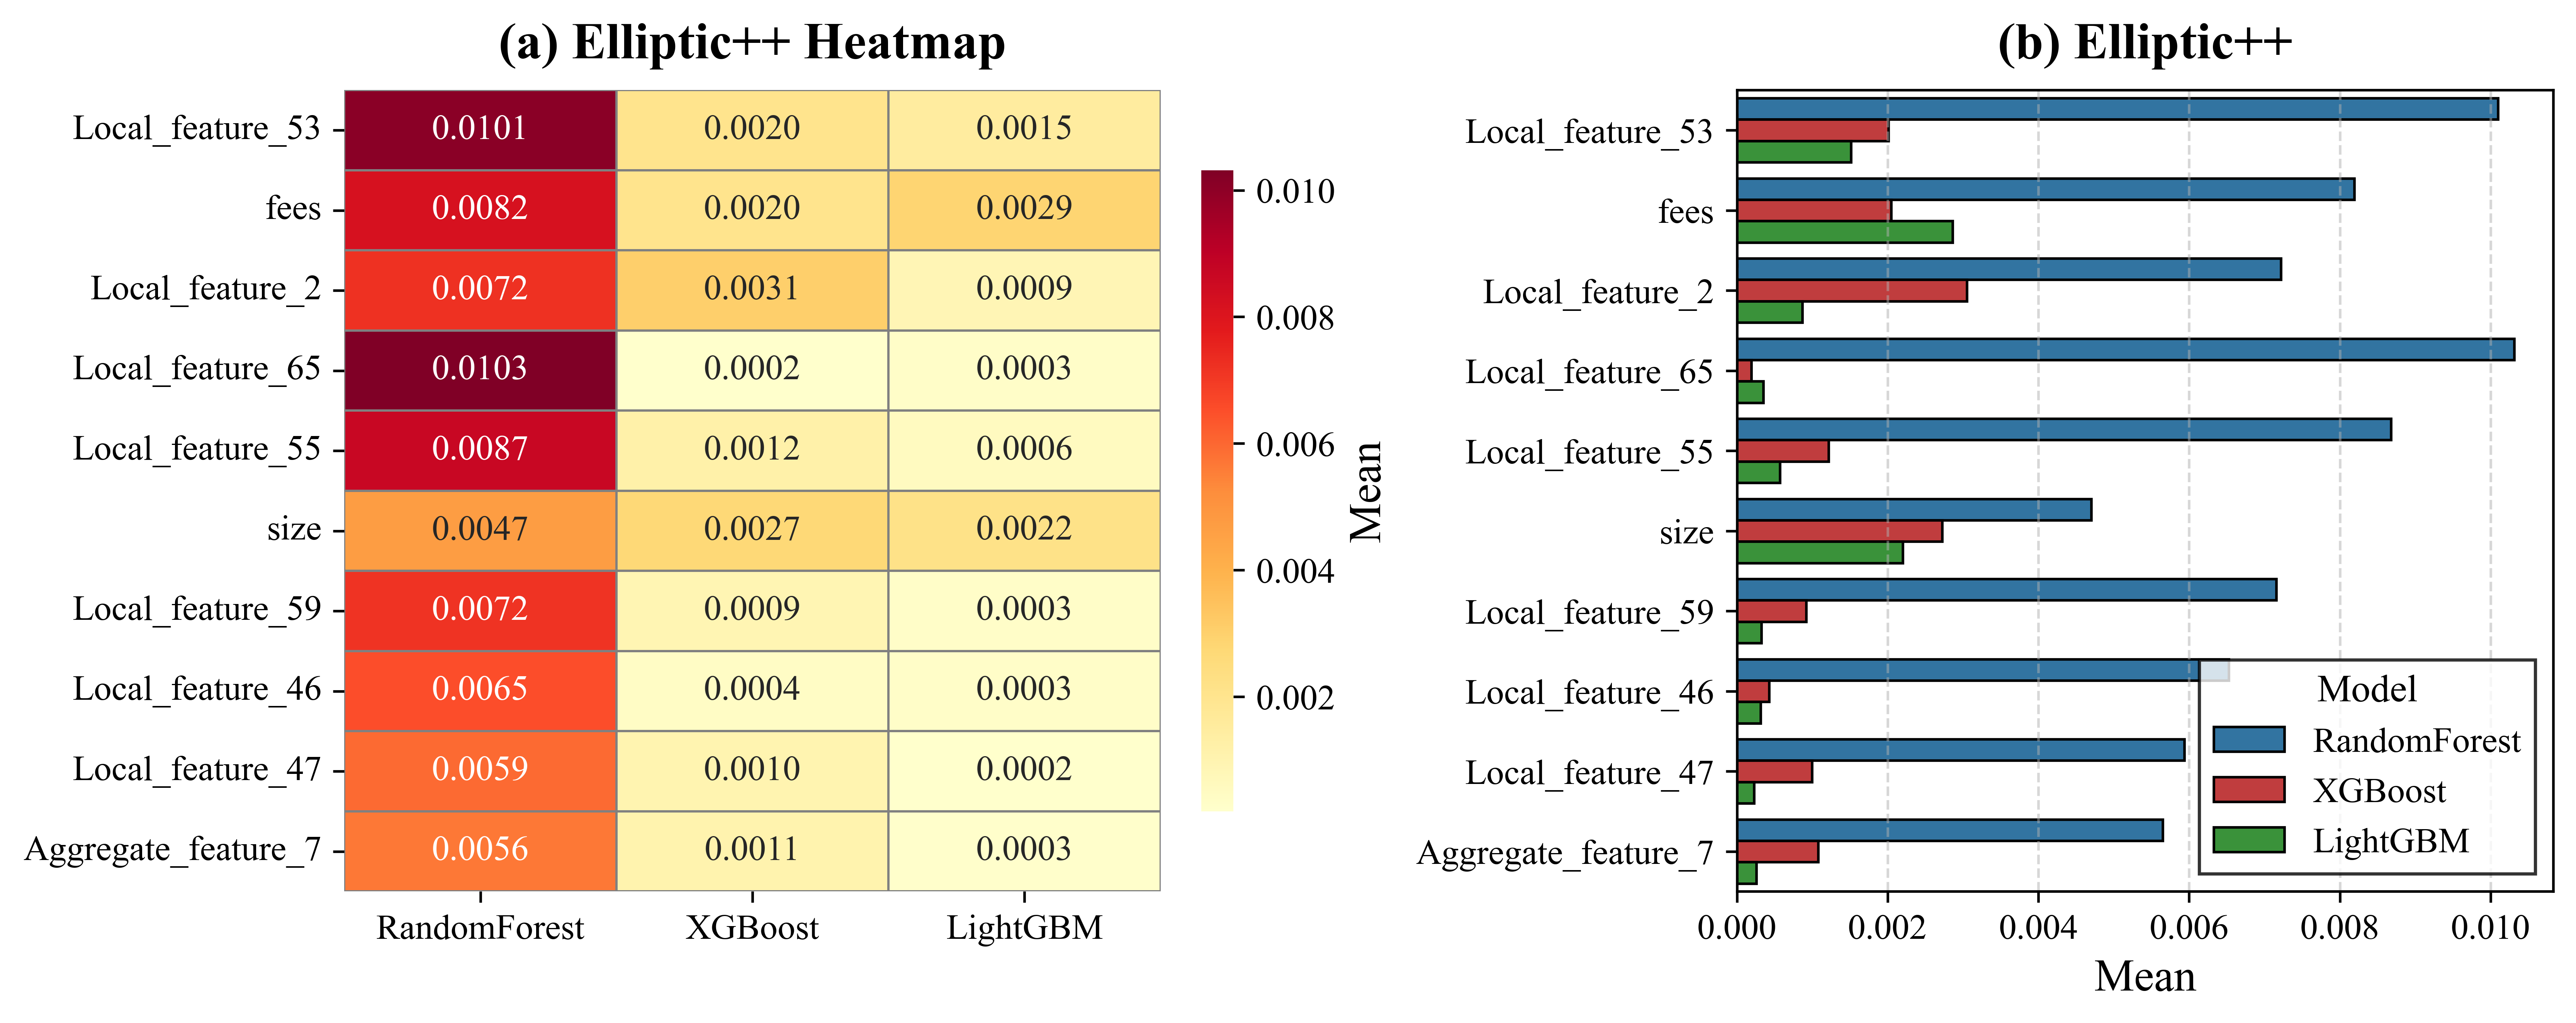

In [22]:

try:
    import shap
    shap_available = True
except Exception as e:
    print("Could not import SHAP (shap)")
    print(e)
    shap_available = False

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if shap_available and X_test_scaled.shape[0] > 0:
    shap.initjs()


    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['xtick.labelsize'] = 11
    plt.rcParams['ytick.labelsize'] = 11
    plt.rcParams['legend.fontsize'] = 11
    plt.rcParams['figure.titlesize'] = 18


    n_background = min(200,X_train_scaled.shape[0])
    n_explain    = min(200,X_test_scaled.shape[0])

    X_background = X_train_scaled[:n_background]
    X_explain    = X_test_scaled[:n_explain]

    print(f"[Elliptic] Background SHAP size: {X_background.shape}")
    print(f"[Elliptic] Explain SHAP size   : {X_explain.shape}")

    models_to_explain = {
        "RandomForest": best_rf,
        "XGBoost":      best_xgb,
        "LightGBM":     best_lgbm,
    }

    mean_abs_dict = {}   

    for name, model in models_to_explain.items():
        print(f"\n================ SHAP for {name} (Elliptic++) ================")


        explainer = shap.TreeExplainer(
            model,
            data=X_background,
            feature_perturbation="interventional",
            model_output="probability"
        )

        sv = explainer.shap_values(
            X_explain,
            check_additivity=False
        )

        if isinstance(sv, list):
            if hasattr(model, "classes_"):
                cls_idx = int(np.where(model.classes_ == 1)[0][0])
            else:
                cls_idx = 1
            sv_pos = np.array(sv[cls_idx])

        elif isinstance(sv, np.ndarray) and sv.ndim == 3:
            if hasattr(model, "classes_"):
                cls_idx = int(np.where(model.classes_ == 1)[0][0])
            else:
                cls_idx = sv.shape[2] - 1
            sv_pos = np.array(sv[:, :, cls_idx])

        else:
            sv_pos = np.array(sv)

        assert sv_pos.ndim == 2, f"sv_pos không phải 2D cho model {name} (shape={sv_pos.shape})"
        print("  sv_pos.shape =", sv_pos.shape, "| ndim =", sv_pos.ndim)


        mean_abs = np.mean(np.abs(sv_pos), axis=0)  
        mean_abs_dict[name] = mean_abs


    df_mean = pd.DataFrame(mean_abs_dict, index=feature_cols)


    top_n = 10 if len(feature_cols) >= 10 else len(feature_cols)
    df_mean['avg'] = df_mean.mean(axis=1)
    df_mean = df_mean.sort_values('avg', ascending=False)
    df_top = df_mean.head(top_n).drop(columns='avg')   


    plt.close('all')
    fig, axes = plt.subplots(
        1, 2,
        figsize=(11, 4.3),   
        dpi=600,
        constrained_layout=True
    )
    ax0, ax1 = axes

  
    sns.heatmap(
        df_top,
        annot=True,
        fmt=".4f",              
        cmap="YlOrRd",
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={"label": "Mean", "shrink": 0.8},
        ax=ax0,
        annot_kws={"size": 11}
    )

    ax0.set_title("(a) Elliptic++ Heatmap", pad=10, fontweight='bold')
    ax0.set_xlabel("")
    ax0.set_ylabel("")
    ax0.set_yticklabels(df_top.index, rotation=0)
    ax0.set_xticklabels(df_top.columns, rotation=0)


    df_long = (
        df_top
        .reset_index()
        .melt(id_vars="index", var_name="Model", value_name="Importance")
        .rename(columns={"index": "Feature"})
    )

    feature_order = df_top.index.tolist()

    sns.barplot(
        data=df_long,
        x="Importance",
        y="Feature",
        hue="Model",
        order=feature_order,
        palette=["#1f77b4", "#d62728", "#2ca02c"],  
        ax=ax1,
        edgecolor='black',
        linewidth=0.8
    )

    ax1.set_title("(b) Elliptic++", pad=10, fontweight='bold')
    ax1.set_xlabel("Mean")
    ax1.set_ylabel("")
    ax1.grid(axis="x", linestyle='--', alpha=0.5)

    ax1.legend(
        title="Model",
        frameon=True,
        fancybox=False,
        edgecolor='black'
    )

    plt.show()




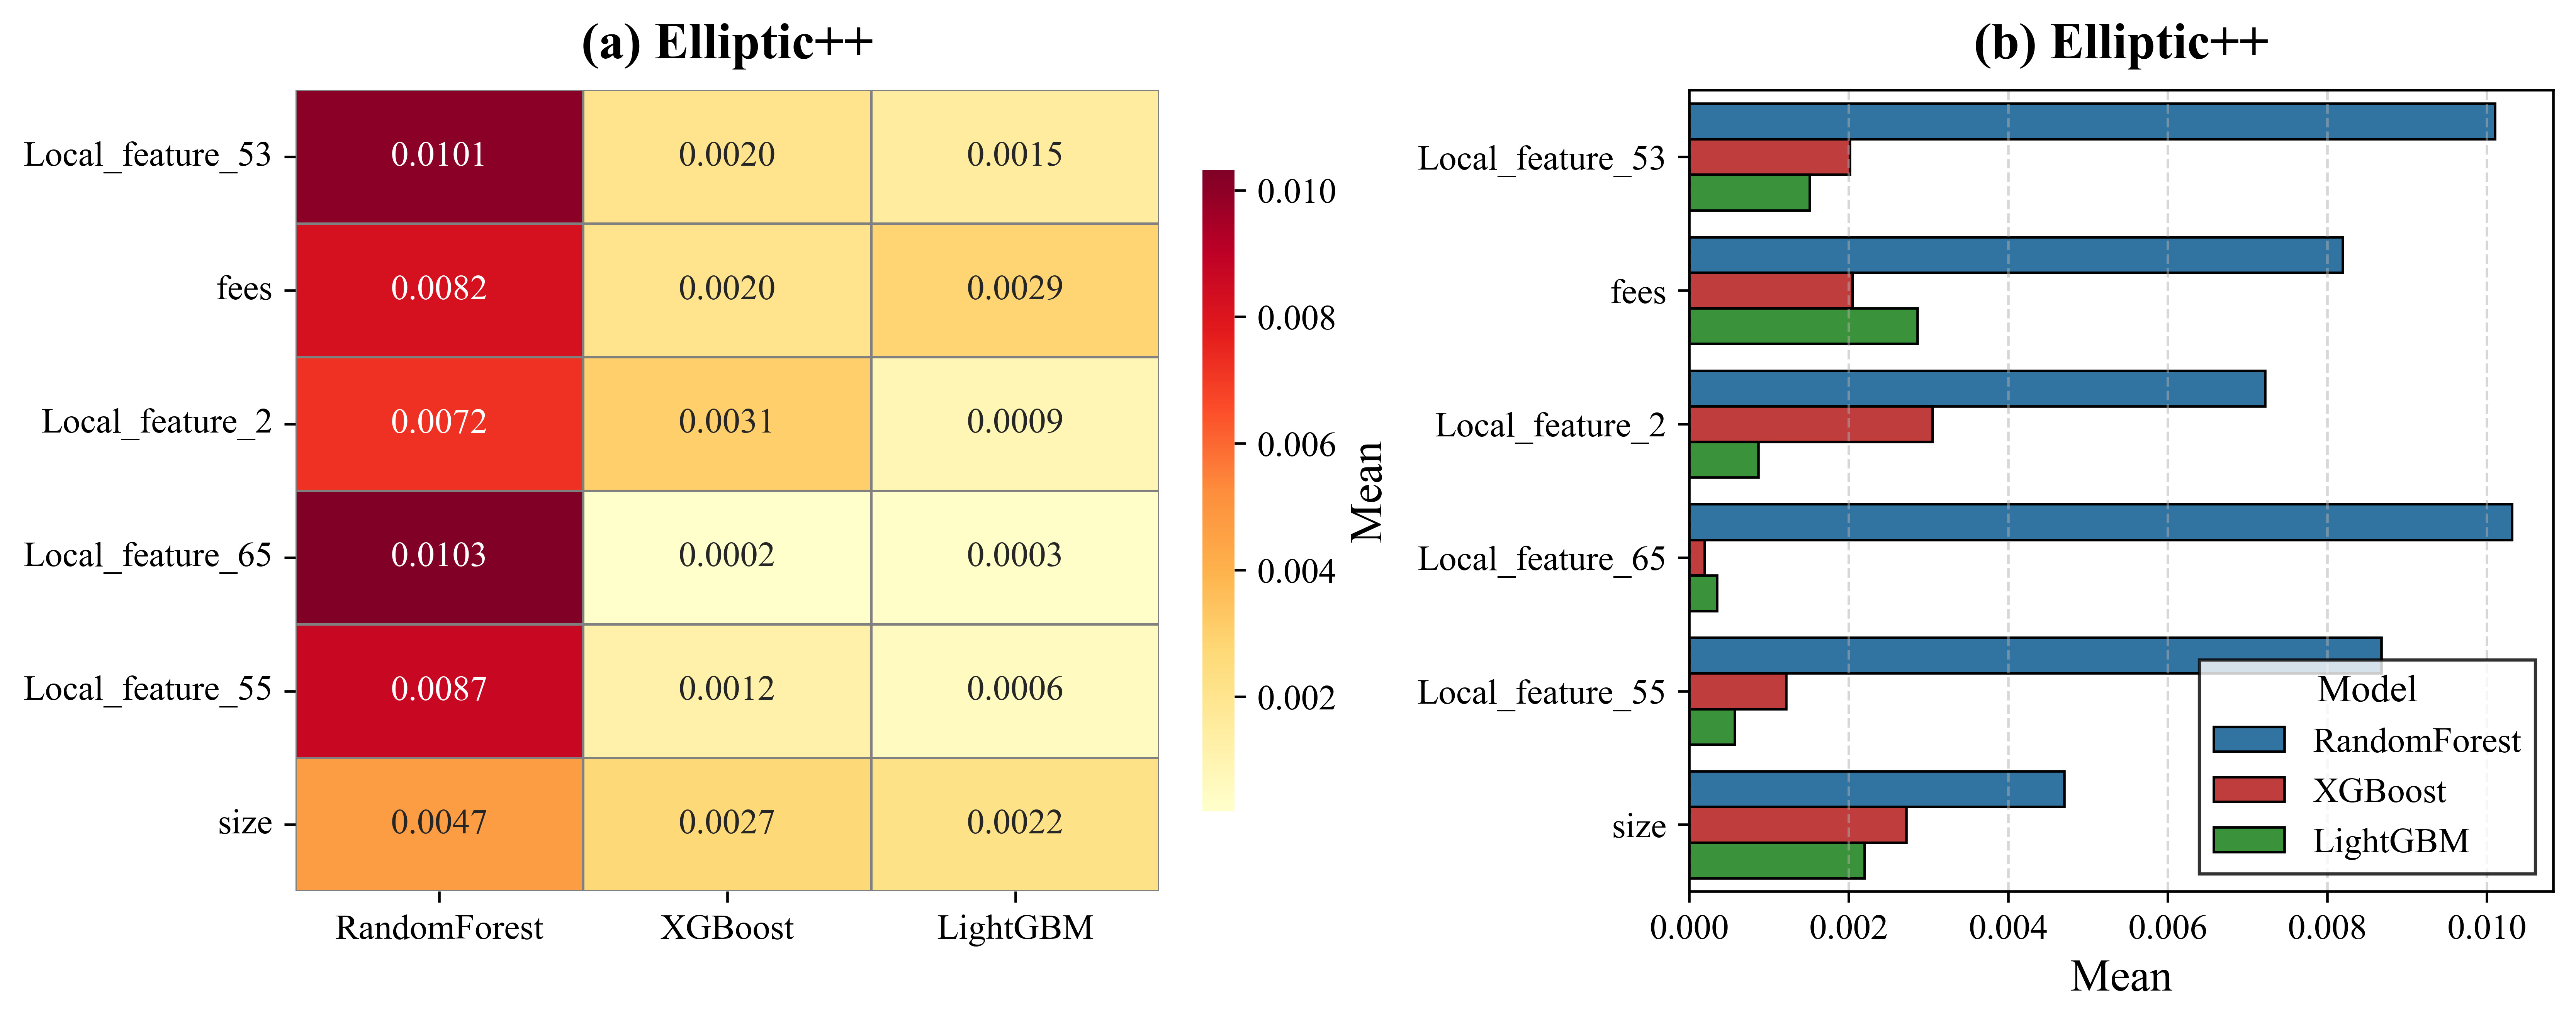

In [23]:

    df_mean = pd.DataFrame(mean_abs_dict, index=feature_cols)


    top_n = 6 if len(feature_cols) >= 10 else len(feature_cols)
    df_mean['avg'] = df_mean.mean(axis=1)
    df_mean = df_mean.sort_values('avg', ascending=False)
    df_top = df_mean.head(top_n).drop(columns='avg') 


    plt.close('all')
    fig, axes = plt.subplots(
        1, 2,
        figsize=(11, 4.3),  
        dpi=600,
        constrained_layout=True
    )
    ax0, ax1 = axes


    sns.heatmap(
        df_top,
        annot=True,
        fmt=".4f",          
        cmap="YlOrRd",
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={"label": "Mean", "shrink": 0.8},
        ax=ax0,
        annot_kws={"size": 11}
    )

    ax0.set_title("(a) Elliptic++", pad=10, fontweight='bold')
    ax0.set_xlabel("")
    ax0.set_ylabel("")
    ax0.set_yticklabels(df_top.index, rotation=0)
    ax0.set_xticklabels(df_top.columns, rotation=0)


    df_long = (
        df_top
        .reset_index()
        .melt(id_vars="index", var_name="Model", value_name="Importance")
        .rename(columns={"index": "Feature"})
    )

    feature_order = df_top.index.tolist()

    sns.barplot(
        data=df_long,
        x="Importance",
        y="Feature",
        hue="Model",
        order=feature_order,
        palette=["#1f77b4", "#d62728", "#2ca02c"],  # giống code mẫu
        ax=ax1,
        edgecolor='black',
        linewidth=0.8
    )

    ax1.set_title("(b) Elliptic++", pad=10, fontweight='bold')
    ax1.set_xlabel("Mean")
    ax1.set_ylabel("")
    ax1.grid(axis="x", linestyle='--', alpha=0.5)

    ax1.legend(
        title="Model",
        frameon=True,
        fancybox=False,
        edgecolor='black'
    )

    fig.savefig("eliptic.png", dpi=600, bbox_inches="tight")




In [20]:
from pathlib import Path
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score

rows = []


base_models = {"RF": best_rf, "XGB": best_xgb, "LGBM": best_lgbm}
for name, model in base_models.items():
    y_pred = model.predict(X_test_scaled)
    y_score = None
    if hasattr(model, 'predict_proba'):
        try:
            y_score = model.predict_proba(X_test_scaled)[:, 1]
        except Exception:
            y_score = None
    elif hasattr(model, 'decision_function'):
        try:
            y_score = model.decision_function(X_test_scaled)
        except Exception:
            y_score = None

    auc = np.nan
    if y_score is not None:
        try:
            auc = roc_auc_score(y_test, y_score)
        except Exception:
            auc = np.nan
    rows.append({
        "seed": int(RANDOM_STATE),
        "model": name,
        "f1_macro": float(f1_score(y_test, y_pred, average="macro")),
        "roc_auc": float(auc)
    })


if "results_df" in globals():
    tmp = results_df.copy()
    tmp["model"] = tmp["ensemble"].astype(str) + "_" + tmp["voting"].astype(str)
    for _, r in tmp.iterrows():
        rows.append({
            "seed": int(RANDOM_STATE),
            "model": str(r["model"]),
            "f1_macro": float(r["f1_macro"]),
            "roc_auc": float(r["roc_auc"]) if "roc_auc" in r else float(np.nan)
        })
else:
    print("WARNING: results_df chưa tồn tại -> chỉ lưu macro-F1 cho 3 base models.")


out_csv = Path(r"D:\elliptic\ellipticv2\runs2\macro_f1_all_models_by_seed.csv")
out_csv.parent.mkdir(parents=True, exist_ok=True)

df_out = pd.DataFrame(rows)

write_header = (not out_csv.exists()) or out_csv.stat().st_size == 0
df_out.to_csv(out_csv, mode="a", header=write_header, index=False)

print("Saved:", out_csv, "| rows:", len(df_out))


Saved: D:\elliptic\ellipticv2\runs2\macro_f1_all_models_by_seed.csv | rows: 55


d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [21]:
import os

out_dir = "outputs2"
os.makedirs(out_dir, exist_ok=True)

csv_path = os.path.join(out_dir, "ensemble_results.csv")
results_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("Saved:", csv_path)

Saved: outputs2\ensemble_results.csv
